# Урок 2. Метрики качества классификации ч.1

В уроке мы разбирали матрицу ошибок и некоторые метрики, основанные на терминах матрицы ошибок. Здесь же посмотрим, как эти метрики применять на практике и что  по ним можно выяснить.

### 1.1
Выкачайте тренировочный датасет Titanic - train.csv - с сайта [kaggle](https://www.kaggle.com/c/titanic/data). С помощью функции pd.read_csv() загрузите данные в датафрейм. Выведите первые 20 строк и проанализируйте данные: какие колонки присутствуют (более конкретная информация по ним есть на сайте kaggle), каким образом в них обозначены данные и какие типы данных используются (используйте pandas.dtypes).

In [1]:
import pandas as pd

In [8]:
df = pd.read_csv('train.csv')
df.head(20)



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [9]:
print(df.dtypes)


PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


### 1.2
Проверьте, имеются ли пропущенные значения в колонках, и выведите сумму всех пропущенных значений в каждой из колонок.

In [14]:
print("Пропущенные значения по колонкам:")
missing_values = df.isnull().sum()
print(missing_values)

Пропущенные значения по колонкам:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


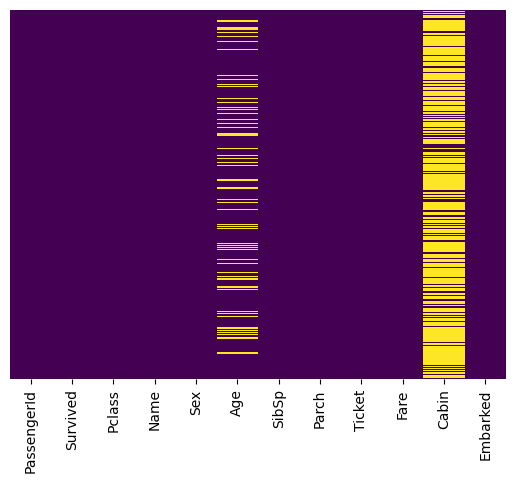

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
#анализ наполненности дата фрейма
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.show()




### 1.3
Замените все пропущенные значения колонки Age на медианы в зависимости от пола человека: т.е. если пол человека в строке с пропущенным значением "male", заменяете пропущенное значение возраста на медиану по всем известным возрастам мужчин, и наоборот. Выведите медианы возраста в зависимости от пола. Пропущенные значения колонок Cabin и Embarked замените на U (Unknown).

Примечание: для группировки по полу можно использовать метод df.groupby(), который имеет встроенные агрегатные функции (в т.ч. для вычисления медианы).  Для установки пропущенных значений в датасете воспользуйтесь функцией df.apply().

In [18]:
import numpy as np
#заменяем значения в столбцах Cabin и Embarked
df['Cabin'] = df['Cabin'].fillna('U')
df['Embarked'] = df['Embarked'].fillna('U')

#группируем столбец age по полу и применяем функцию apply к столбцу age
df['Age'] = df.groupby('Sex')['Age'].apply(lambda x: x.fillna(x.median())).reset_index(drop=True)
missing_values = df.isnull().sum()   
print(missing_values)




PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


In [19]:
df.head(20)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,35.0,1,0,A/5 21171,7.2500,U,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,27.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,55.0,0,0,STON/O2. 3101282,7.9250,U,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,27.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,14.0,0,0,373450,8.0500,U,S
5,6,0,3,"Moran, Mr. James",male,40.0,0,0,330877,8.4583,U,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,19.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,5.0,3,1,349909,21.0750,U,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,17.0,0,2,347742,11.1333,U,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,28.0,1,0,237736,30.0708,U,C


### 1.4
Выведите возраст пассажиров с PassengerID = [6, 20]. Убедитесь, что заполнены все пропущенные значения (воспользуйтесь функцией df.isnull() ).

In [22]:
ages = df.loc[df['PassengerId'].isin([6, 20]), ['PassengerId', 'Age']]
print(ages)


    PassengerId   Age
5             6  40.0
19           20  50.0


Так как не все классификаторы могут работать с категориальными признаками, в данном случае необходимо заменить их на числовые.

Также можно было бы выделить расширенные признаки, такие как статус пассажира (Mr., Mrs., Miss., Dr., Master. и т.д.), собственный индекс билета, индекс палубы и другие, но здесь ограничимся выбором более простых признаков.

### 1.5
В колонке Sex замените значения на 0, если пол "male", и на 1, если "female". В колонке Embarked замените параметры "U", "S", "C", "Q" на 0, 1, 2, 3 соответственно. Отбросьте колонки PassengerId, Name, Ticket, Cabin. Выведите первые 20 строк получившегося набора данных.

In [23]:
#замена значений в колонке Sex
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

#замена значений в колонке Embarked
df['Embarked'] = df['Embarked'].map({'U': 0, 'S': 1, 'C': 2, 'Q': 3})

#отбрасываем ненужные колонки
df = df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)

#выводим первые 20 строк
df.head(20)




,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,35.0,1,0,7.2500,1
1,1,1,1,27.0,1,0,71.2833,2
2,1,3,1,55.0,0,0,7.9250,1
3,1,1,1,27.0,1,0,53.1000,1
4,0,3,0,14.0,0,0,8.0500,1
5,0,3,0,40.0,0,0,8.4583,3
6,0,1,0,19.0,0,0,51.8625,1
7,0,3,0,5.0,3,1,21.0750,1
8,1,3,1,17.0,0,2,11.1333,1
9,1,2,1,28.0,1,0,30.0708,2


### 1.6
Приступим к построению классификаторов. **Условимся, что, если функция или объект модели имеют параметр random_state, то устанавливаем его равным 17 в каждом из случаев.**

Разделите данные на тренировочный и тестовый датасеты, установив размер тестового как 0.25 (первая колонка Survived является целевой, поэтому необходимо сначала ее отделить от признаков).

In [28]:
from sklearn.model_selection import train_test_split

In [25]:
df.keys()

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked'],
      dtype='object')

In [30]:
passenger_dataset = df.drop('Pclass', axis=1)  #удаляем целевую переменную из признаков
passenger_dataset

,Survived,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,0,35.0,1,0,7.2500,1
1,1,1,27.0,1,0,71.2833,2
2,1,1,55.0,0,0,7.9250,1
3,1,1,27.0,1,0,53.1000,1
4,0,0,14.0,0,0,8.0500,1
...,...,...,...,...,...,...,...
886,0,0,29.0,0,0,13.0000,1
887,1,1,4.0,0,0,30.0000,1
888,0,1,19.0,1,2,23.4500,1
889,1,0,26.0,0,0,30.0000,2


In [31]:
#целевая переменная
y = df['Pclass']

#разделяем на обучающую и тестовую выборки
x_train, x_test, y_train, y_test = train_test_split(passenger_dataset, y, test_size=0.25, random_state=17)
print(f'X_train shape: {x_train.shape}, y_train shape: {y_train.shape},\n'
      f'X_test shape: {x_test.shape}, y_test shape: {y_test.shape}')

X_train shape: (668, 7), y_train shape: (668,),
X_test shape: (223, 7), y_test shape: (223,)


### 1.7
Обучите на полученных выборках несколько классификаторов, которые импортированы ниже.

**Примечание: в методе ближайших соседей используйте количество соседей, равное 5.**

In [32]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

In [34]:
#обучение по методу ближайших соседей и записывание предсказаний в переменную
knn = KNeighborsClassifier(n_neighbors=5)
knn_model = knn.fit(x_train, y_train)
knn_predictions = knn.predict(x_test)
knn_predictions

array([3, 1, 3, 3, 1, 3, 3, 3, 2, 3, 3, 1, 1, 1, 3, 3, 3, 3, 1, 3, 3, 2,
       1, 3, 1, 1, 1, 3, 3, 3, 3, 3, 3, 3, 1, 3, 2, 3, 3, 2, 3, 1, 2, 3,
       1, 2, 1, 2, 1, 1, 1, 2, 3, 2, 3, 1, 3, 3, 2, 3, 2, 3, 1, 3, 3, 1,
       2, 3, 1, 3, 3, 3, 3, 1, 3, 1, 2, 3, 3, 3, 3, 1, 1, 3, 3, 3, 2, 3,
       1, 3, 3, 2, 3, 3, 1, 3, 2, 2, 3, 1, 2, 1, 2, 1, 2, 2, 3, 1, 3, 1,
       3, 3, 2, 1, 3, 2, 2, 3, 2, 3, 3, 2, 1, 3, 3, 3, 3, 2, 3, 1, 3, 3,
       2, 3, 3, 3, 1, 3, 1, 2, 2, 3, 2, 1, 2, 3, 1, 2, 1, 3, 1, 1, 2, 2,
       3, 3, 2, 3, 1, 1, 1, 1, 3, 2, 3, 1, 2, 2, 2, 3, 1, 3, 1, 3, 1, 3,
       2, 2, 2, 3, 3, 1, 1, 2, 3, 2, 2, 3, 3, 2, 3, 3, 1, 2, 1, 2, 3, 3,
       2, 2, 3, 3, 3, 3, 1, 2, 3, 1, 3, 3, 1, 3, 1, 3, 1, 1, 3, 1, 2, 3,
       3, 3, 3], dtype=int64)

In [46]:
#обучение по методу GaussianNB
nb = GaussianNB()
nb_model = nb.fit(x_train, y_train)
nb_predictions = nb.predict(x_test)
nb_predictions

array([3, 1, 2, 3, 1, 3, 3, 3, 3, 2, 2, 3, 1, 3, 2, 3, 3, 3, 1, 2, 2, 3,
       2, 3, 2, 2, 1, 3, 2, 3, 3, 3, 3, 3, 1, 2, 3, 3, 3, 3, 3, 1, 3, 3,
       2, 3, 1, 2, 1, 3, 1, 1, 3, 3, 3, 1, 3, 3, 3, 3, 2, 3, 1, 3, 2, 2,
       2, 3, 1, 2, 2, 3, 3, 2, 3, 3, 1, 3, 3, 3, 2, 1, 1, 3, 3, 3, 3, 3,
       2, 3, 3, 1, 3, 3, 3, 2, 2, 3, 3, 1, 2, 1, 3, 1, 1, 2, 3, 2, 3, 2,
       3, 3, 3, 1, 3, 2, 2, 3, 2, 3, 3, 3, 1, 3, 3, 3, 3, 1, 3, 2, 3, 3,
       3, 2, 3, 3, 2, 3, 1, 2, 3, 3, 3, 1, 2, 3, 3, 3, 1, 3, 1, 2, 2, 3,
       3, 3, 3, 3, 1, 2, 1, 1, 2, 3, 3, 1, 2, 2, 3, 3, 1, 3, 1, 3, 1, 3,
       2, 2, 3, 3, 3, 3, 1, 3, 3, 2, 2, 2, 3, 2, 3, 3, 2, 3, 3, 3, 3, 3,
       2, 3, 3, 3, 3, 3, 3, 2, 3, 1, 3, 2, 1, 3, 2, 2, 1, 1, 3, 3, 3, 2,
       3, 3, 3], dtype=int64)

In [49]:
dtc = DecisionTreeClassifier()
dtc_model = dtc.fit(x_train, y_train)
dtc_predictions = dtc.predict(x_test)
dtc_predictions

array([3, 1, 3, 3, 1, 2, 3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 1, 2, 3, 3,
       2, 3, 2, 1, 1, 3, 3, 3, 2, 3, 3, 3, 1, 3, 3, 3, 3, 3, 3, 1, 3, 3,
       1, 2, 3, 2, 1, 3, 1, 1, 3, 2, 3, 1, 3, 3, 2, 3, 3, 3, 1, 2, 2, 2,
       2, 3, 2, 2, 2, 3, 3, 2, 2, 1, 1, 3, 3, 3, 2, 1, 1, 3, 3, 3, 2, 3,
       1, 3, 3, 1, 2, 3, 3, 3, 2, 3, 3, 1, 2, 2, 3, 1, 1, 3, 3, 3, 3, 1,
       3, 3, 2, 1, 3, 3, 3, 2, 2, 3, 3, 3, 1, 3, 3, 3, 3, 2, 3, 2, 3, 3,
       2, 2, 2, 3, 2, 3, 1, 2, 2, 3, 3, 1, 2, 3, 3, 2, 1, 3, 1, 1, 2, 2,
       3, 3, 3, 3, 2, 1, 1, 3, 3, 2, 2, 1, 1, 2, 2, 3, 1, 3, 1, 3, 1, 3,
       3, 1, 1, 3, 3, 2, 1, 3, 3, 2, 2, 3, 3, 3, 3, 3, 2, 3, 3, 2, 3, 3,
       2, 3, 3, 3, 3, 3, 3, 2, 3, 1, 3, 3, 2, 3, 1, 3, 1, 1, 3, 3, 2, 3,
       3, 3, 3], dtype=int64)

In [60]:
lr = LogisticRegression(random_state=17, max_iter=1000)
lr_model = lr.fit(x_train, y_train)
lr_predictions = lr.predict(x_test)
lr_predictions

array([3, 1, 3, 3, 1, 3, 3, 3, 3, 3, 3, 3, 1, 3, 2, 3, 3, 3, 1, 3, 3, 3,
       2, 3, 2, 1, 1, 3, 3, 3, 3, 3, 3, 3, 1, 3, 3, 3, 3, 3, 3, 1, 3, 3,
       1, 3, 1, 2, 1, 3, 1, 1, 3, 3, 3, 1, 3, 3, 2, 3, 3, 3, 1, 3, 1, 2,
       2, 3, 1, 1, 2, 3, 3, 2, 3, 3, 1, 3, 3, 3, 2, 1, 1, 3, 3, 3, 3, 3,
       1, 3, 3, 1, 1, 3, 3, 3, 2, 3, 3, 1, 2, 2, 3, 1, 1, 2, 3, 1, 3, 1,
       3, 3, 3, 1, 3, 2, 3, 3, 2, 3, 3, 3, 1, 3, 3, 3, 3, 2, 3, 2, 3, 3,
       3, 3, 3, 3, 2, 3, 1, 2, 3, 3, 3, 1, 2, 3, 3, 2, 1, 3, 1, 1, 2, 3,
       3, 3, 3, 3, 2, 2, 1, 1, 2, 3, 3, 1, 1, 3, 3, 3, 1, 3, 1, 3, 1, 3,
       3, 2, 1, 3, 3, 2, 1, 3, 3, 2, 2, 3, 3, 3, 3, 3, 2, 3, 3, 3, 3, 3,
       2, 3, 3, 3, 3, 3, 3, 2, 3, 1, 3, 3, 1, 3, 1, 3, 1, 1, 3, 3, 3, 3,
       3, 3, 3], dtype=int64)

Очевидно, в этом случае использовать метрику accuracy, которую мы применяли до этого, не совсем правильно: она не даст верную оценку классификатору, потому как выживших явно меньше, чем погибших.

Вспомним про такие метрики как точность и полнота. Здесь они подойдут хорошо, так как у нас имеются положительный и отрицательный классы, и определить корректно один из них может оказаться более важным .

### 1.8
В каждом из пунктов следующего теста выберите, что важнее максимизировать: точность (precision) или полноту (recall). Выпишите ответы.

1. Вероятность того, что при определенной поломке самолета он сможет долететь до пункта назначения (1 - долетел, 0 - не долетел).
2. Предсказание, представляет ли человек опасность, по анализу психического состояния (1 - представляет опасность, 0 - не представляет опасности).
3. Предсказание ухода клиента (1 - клиент ушел, 0 - остался).
4. Выявление рака на основе медицинских показателей (1 - болен раком, 0 - здоров).
5. Предсказание летальности при наблюдаемой мутации (1 - выживание, 0 - летальный исход).
6. Определение важности происшествия для экстренных служб (1 - важно, 0 - неважно).
7. Окупятся ли вложения в бизнес (1 - окупятся, 0 - не окупятся).

Ваш ответ:

1. <recall>
2. <recall>
3. <recall>
4. <recall>
5. <recall>
6. <recall>
7. <precision>

### 1.9
Определите, что важнее использовать в случае датасета Titanic: полноту или точность. Объясните, почему.

### 1.10
Для каждого классификатора выведите матрицу ошибок и самостоятельно рассчитайте метрику recall (расчеты должны присутствовать). Проверьте расчеты, воспользовавшись встроенной метрикой recall_score.

In [ ]:
#Для датасета Titanic лучше использовать полноту, потому что важнее не ошибится в значениях с летальным исходом

In [33]:
from sklearn.metrics import confusion_matrix, recall_score
from sklearn.metrics import accuracy_score

In [36]:
#Снатала получаем матрицу ошибок 
cm = confusion_matrix(y_test, knn_predictions)
print("Матрица ошибок:")
print(cm)

Матрица ошибок:
[[44  8  2]
 [ 5 31 12]
 [12 14 95]]


In [45]:
#Recall для каждого класса
recall_0 = cm[0, 0] / np.sum(cm[0, :]) 
recall_1 = cm[1, 1] / np.sum(cm[1, :])  
recall_2 = cm[2, 2] / np.sum(cm[2, :])  

print(f"Recall класса 0: {recall_0:.4f} = {cm[0, 0]} / {np.sum(cm[0, :])}")
print(f"Recall класса 1: {recall_1:.4f} = {cm[1, 1]} / {np.sum(cm[1, :])}")
print(f"Recall класса 2: {recall_2:.4f} = {cm[2, 2]} / {np.sum(cm[2, :])}")

#Macro recall
macro_recall_manual = (recall_0 + recall_1 + recall_2) / 3
print(f"Macro recall (среднее): {macro_recall_manual:.4f}")

#проверка встроенной функцией  recall_score
recall_macro = recall_score(y_test, knn_predictions, average='macro')
recall_per_class = recall_score(y_test, knn_predictions, average=None)

print(f"\nRecall по классам (sklearn): {recall_per_class}")
print(f"Macro recall (sklearn): {recall_macro:.4f}")


Recall класса 0: 0.8148 = 44 / 54
Recall класса 1: 0.6458 = 31 / 48
Recall класса 2: 0.7851 = 95 / 121
Macro recall (среднее): 0.7486

Recall по классам (sklearn): [0.81481481 0.64583333 0.78512397]
Macro recall (sklearn): 0.7486


In [52]:
#Снатала получаем матрицу ошибок 
cm = confusion_matrix(y_test, nb_predictions)
print("Матрица ошибок:")
print(cm)

Матрица ошибок:
[[ 37  13   4]
 [  1  25  22]
 [  3  17 101]]


In [53]:
#Recall для каждого класса
recall_0 = cm[0, 0] / np.sum(cm[0, :])  
recall_1 = cm[1, 1] / np.sum(cm[1, :])  
recall_2 = cm[2, 2] / np.sum(cm[2, :])  

print(f"Recall класса 0: {recall_0:.4f} = {cm[0, 0]} / {np.sum(cm[0, :])}")
print(f"Recall класса 1: {recall_1:.4f} = {cm[1, 1]} / {np.sum(cm[1, :])}")
print(f"Recall класса 2: {recall_2:.4f} = {cm[2, 2]} / {np.sum(cm[2, :])}")

#Macro recall
macro_recall_manual = (recall_0 + recall_1 + recall_2) / 3
print(f"Macro recall (среднее): {macro_recall_manual:.4f}")

#проверка встроенной функцией  recall_score
recall_macro = recall_score(y_test, nb_predictions, average='macro')
recall_per_class = recall_score(y_test, nb_predictions, average=None)

print(f"\nRecall по классам (sklearn): {recall_per_class}")
print(f"Macro recall (sklearn): {recall_macro:.4f}")

Recall класса 0: 0.6852 = 37 / 54
Recall класса 1: 0.5208 = 25 / 48
Recall класса 2: 0.8347 = 101 / 121
Macro recall (среднее): 0.6802

Recall по классам (sklearn): [0.68518519 0.52083333 0.83471074]
Macro recall (sklearn): 0.6802


In [54]:
cm = confusion_matrix(y_test, dtc_predictions)
print("Матрица ошибок:")
print(cm)

Матрица ошибок:
[[ 42  11   1]
 [  2  38   8]
 [  0   5 116]]


In [55]:
#Recall для каждого класса
recall_0 = cm[0, 0] / np.sum(cm[0, :])  
recall_1 = cm[1, 1] / np.sum(cm[1, :])  
recall_2 = cm[2, 2] / np.sum(cm[2, :])  

print(f"Recall класса 0: {recall_0:.4f} = {cm[0, 0]} / {np.sum(cm[0, :])}")
print(f"Recall класса 1: {recall_1:.4f} = {cm[1, 1]} / {np.sum(cm[1, :])}")
print(f"Recall класса 2: {recall_2:.4f} = {cm[2, 2]} / {np.sum(cm[2, :])}")

#Macro recall
macro_recall_manual = (recall_0 + recall_1 + recall_2) / 3
print(f"Macro recall (среднее): {macro_recall_manual:.4f}")

#проверка встроенной функцией  recall_score
recall_macro = recall_score(y_test, dtc_predictions, average='macro')
recall_per_class = recall_score(y_test, dtc_predictions, average=None)

print(f"\nRecall по классам (sklearn): {recall_per_class}")
print(f"Macro recall (sklearn): {recall_macro:.4f}")

Recall класса 0: 0.7778 = 42 / 54
Recall класса 1: 0.7917 = 38 / 48
Recall класса 2: 0.9587 = 116 / 121
Macro recall (среднее): 0.8427

Recall по классам (sklearn): [0.77777778 0.79166667 0.95867769]
Macro recall (sklearn): 0.8427


In [61]:
cm = confusion_matrix(y_test, lr_predictions)
print("Матрица ошибок:")
print(cm)

Матрица ошибок:
[[ 44   7   3]
 [  1  25  22]
 [  5   1 115]]


In [62]:
#Recall для каждого класса
recall_0 = cm[0, 0] / np.sum(cm[0, :])  
recall_1 = cm[1, 1] / np.sum(cm[1, :])  
recall_2 = cm[2, 2] / np.sum(cm[2, :])  

print(f"Recall класса 0: {recall_0:.4f} = {cm[0, 0]} / {np.sum(cm[0, :])}")
print(f"Recall класса 1: {recall_1:.4f} = {cm[1, 1]} / {np.sum(cm[1, :])}")
print(f"Recall класса 2: {recall_2:.4f} = {cm[2, 2]} / {np.sum(cm[2, :])}")

#Macro recall
macro_recall_manual = (recall_0 + recall_1 + recall_2) / 3
print(f"Macro recall (среднее): {macro_recall_manual:.4f}")

#проверка встроенной функцией  recall_score
recall_macro = recall_score(y_test, lr_predictions, average='macro')
recall_per_class = recall_score(y_test, lr_predictions, average=None)

print(f"\nRecall по классам (sklearn): {recall_per_class}")
print(f"Macro recall (sklearn): {recall_macro:.4f}")

Recall класса 0: 0.8148 = 44 / 54
Recall класса 1: 0.5208 = 25 / 48
Recall класса 2: 0.9504 = 115 / 121
Macro recall (среднее): 0.7620

Recall по классам (sklearn): [0.81481481 0.52083333 0.95041322]
Macro recall (sklearn): 0.7620


### 1.11
Выберите ту модель, на которой метрика recall давала лучший ответ, и рассчитайте для нее precision, используя встроенную функцию.

In [63]:
from sklearn.metrics import precision_score

In [65]:

best_precision = precision_score(y_test, dtc_predictions, average='macro')
print(f"Precision лучшей модели: {best_precision:.4f}")


Precision лучшей модели: 0.8621
